# 🚗 Car Price Prediction with Machine Learning

## CodeAlpha Data Science Internship – Task 3

This project focuses on predicting car prices using machine learning regression techniques.

The project includes:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Categorical data encoding
- Regression model training
- Model evaluation
- Actual vs Predicted price visualization
- Feature importance analysis
- New car price prediction

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/car data.csv')

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission   

In [5]:
# Statistical summary
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
print("Fuel Types:")
print(df['Fuel_Type'].value_counts())

print("\nSelling Types:")
print(df['Selling_type'].value_counts())

print("\nTransmission Types:")
print(df['Transmission'].value_counts())

print("\nOwner Counts:")
print(df['Owner'].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling Types:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner Counts:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


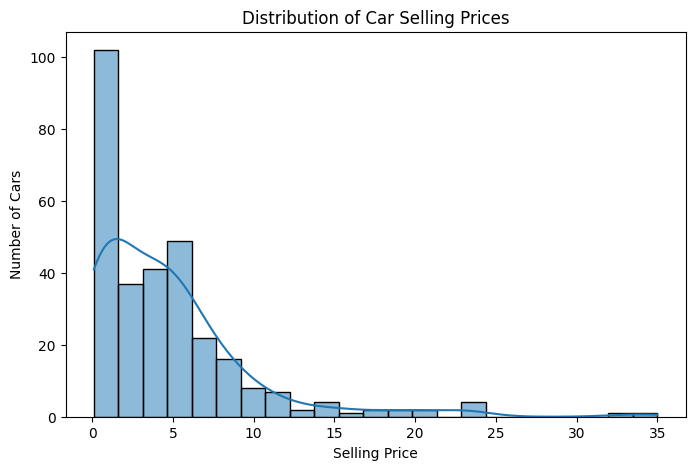

In [7]:
# Distribution of Selling Price

plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

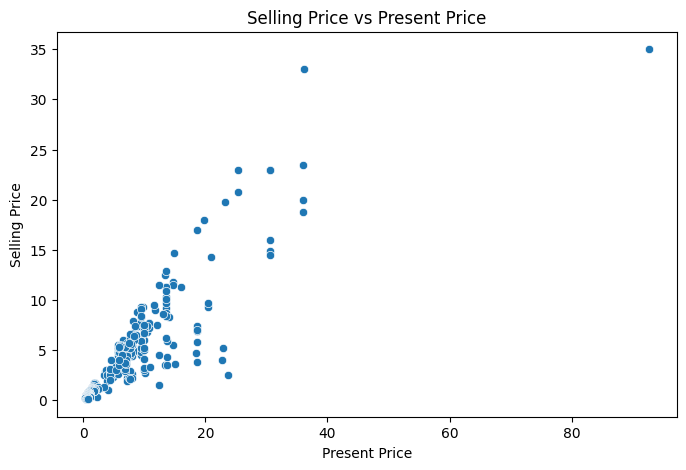

In [8]:
# Selling Price vs Present Price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price')
plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

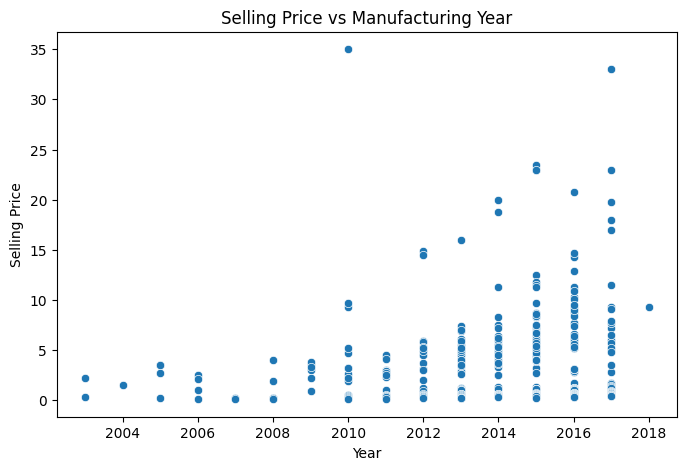

In [9]:
# Selling Price vs Year

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Year', y='Selling_Price')
plt.title('Selling Price vs Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

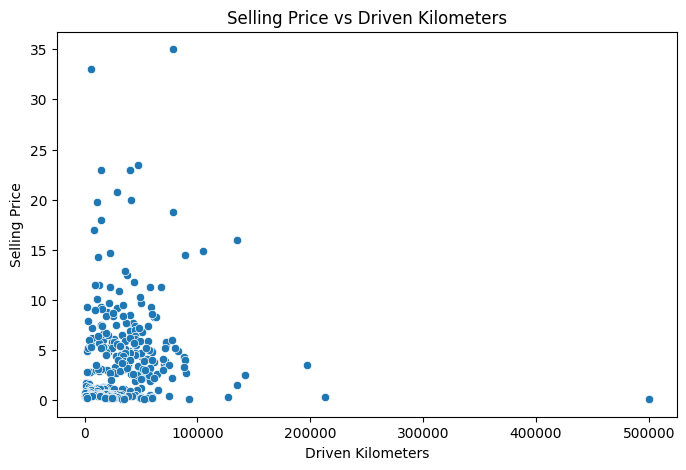

In [10]:
# Selling Price vs Driven Kilometers

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Driven_kms', y='Selling_Price')
plt.title('Selling Price vs Driven Kilometers')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.show()

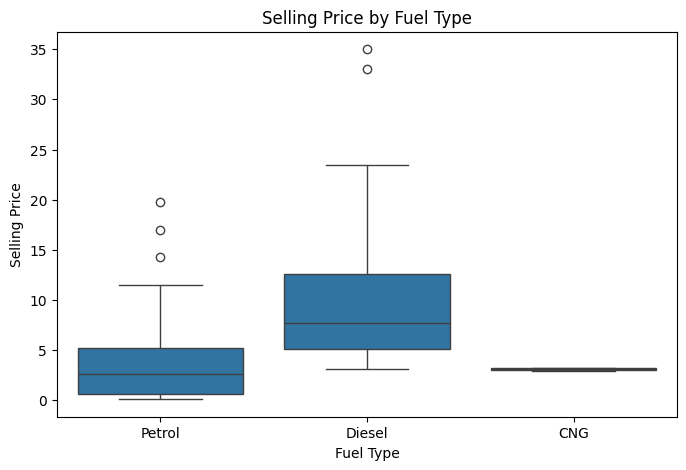

In [11]:
# Selling Price by Fuel Type

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

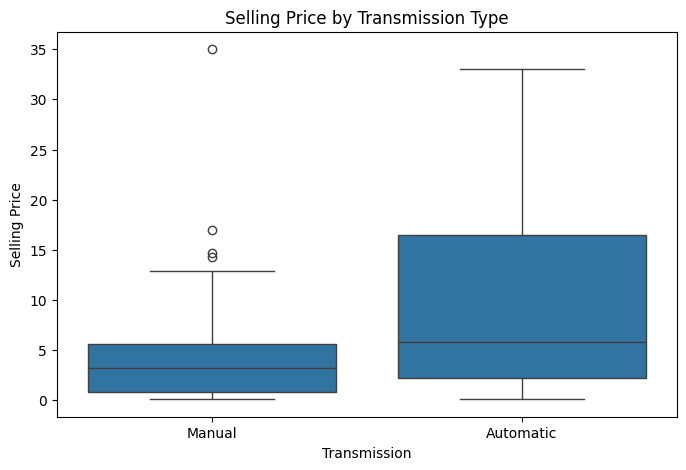

In [12]:
# Selling Price by Transmission

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.show()

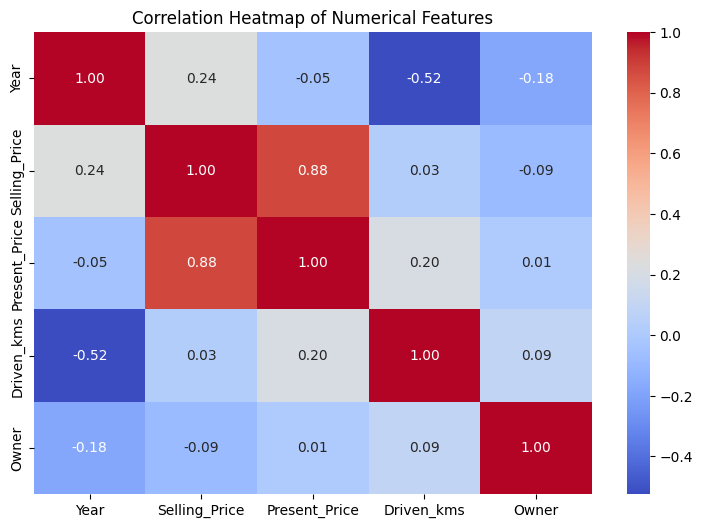

In [13]:
# Correlation between numerical features

numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [14]:
# Create a copy for preprocessing
car_df = df.copy()

# Create Car_Age feature
current_year = 2026
car_df['Car_Age'] = current_year - car_df['Year']

# Display the new feature
car_df[['Year', 'Car_Age', 'Selling_Price']].head()

,Year,Car_Age,Selling_Price
0,2014,12,3.35
1,2013,13,4.75
2,2017,9,7.25
3,2011,15,2.85
4,2014,12,4.60


In [15]:
# Remove Car_Name and original Year
car_df = car_df.drop(['Car_Name', 'Year'], axis=1)

# Display remaining columns
print("Columns after feature engineering:")
print(car_df.columns.tolist())

car_df.head()

Columns after feature engineering:
['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [16]:
# One-hot encode categorical features

car_df = pd.get_dummies(
    car_df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

# Display the processed dataset
car_df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [17]:
print("Processed Dataset Shape:", car_df.shape)

print("\nProcessed Columns:")
print(car_df.columns.tolist())

print("\nData Types:")
print(car_df.dtypes)

Processed Dataset Shape: (301, 9)

Processed Columns:
['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']

Data Types:
Selling_Price              float64
Present_Price              float64
Driven_kms                   int64
Owner                        int64
Car_Age                      int64
Fuel_Type_Diesel              bool
Fuel_Type_Petrol              bool
Selling_type_Individual       bool
Transmission_Manual           bool
dtype: object


In [18]:
# Features and target variable

X = car_df.drop('Selling_Price', axis=1)
y = car_df['Selling_Price']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (301, 8)
Target Shape: (301,)


In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 240
Testing samples: 61


In [20]:
from sklearn.linear_model import LinearRegression

# Create and train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
linear_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [21]:
from sklearn.tree import DecisionTreeRegressor

# Create and train Decision Tree model
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

# Make predictions
tree_pred = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [22]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest model
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

forest_model.fit(X_train, y_train)

# Make predictions
forest_pred = forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to evaluate regression models
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

# Evaluate all models
results = []

results.append(evaluate_model(
    'Linear Regression',
    y_test,
    linear_pred
))

results.append(evaluate_model(
    'Decision Tree',
    y_test,
    tree_pred
))

results.append(evaluate_model(
    'Random Forest',
    y_test,
    forest_pred
))

# Display results
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.216374,1.865838,0.848871
1,Decision Tree,0.809392,1.234918,0.933797
2,Random Forest,0.630817,0.949471,0.960865


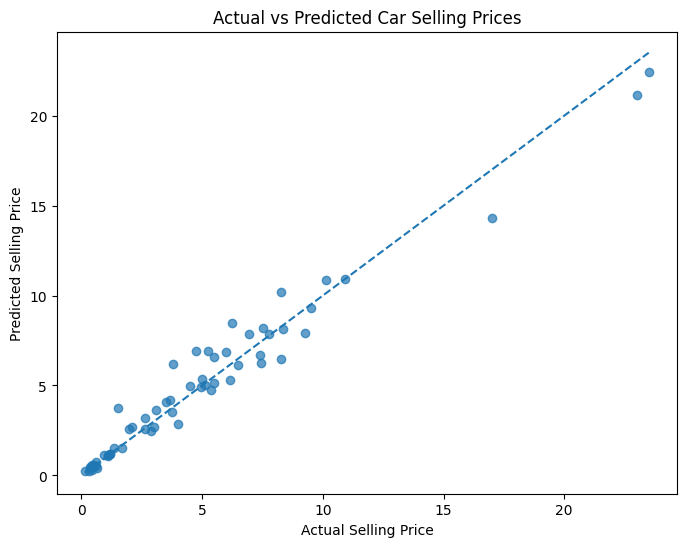

In [24]:
# Actual vs Predicted Selling Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, forest_pred, alpha=0.7)

# Perfect prediction line
min_price = min(y_test.min(), forest_pred.min())
max_price = max(y_test.max(), forest_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Selling Prices')
plt.show()

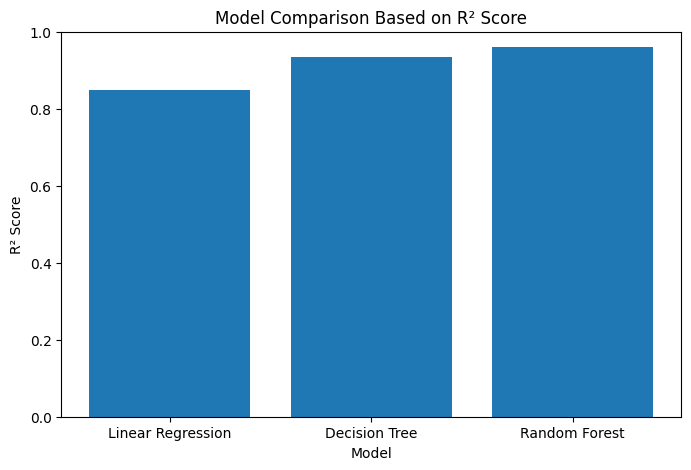

In [25]:
# Compare R² Scores of all models

plt.figure(figsize=(8, 5))

plt.bar(results_df['Model'], results_df['R2 Score'])

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Model Comparison Based on R² Score')
plt.ylim(0, 1)

plt.show()

In [26]:
# Feature Importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
0            Present_Price    0.877499
3                  Car_Age    0.062501
1               Driven_kms    0.037604
7      Transmission_Manual    0.011108
5         Fuel_Type_Petrol    0.004882
6  Selling_type_Individual    0.003218
4         Fuel_Type_Diesel    0.001998
2                    Owner    0.001191


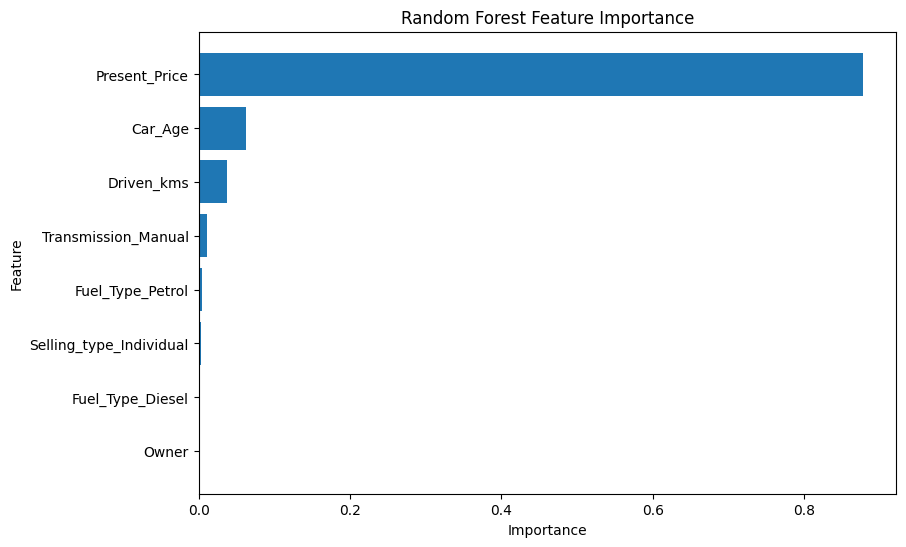

In [27]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.show()

The Random Forest model identifies the most influential features used for predicting the selling price of a car.

In [28]:
# Function to predict the selling price of a new car

def predict_car_price(present_price, driven_kms, fuel_type,
                      selling_type, transmission, owner, car_age):

    # Create input dictionary using the same features as training data
    input_data = pd.DataFrame({
        'Car_Age': [car_age],
        'Present_Price': [present_price],
        'Driven_kms': [driven_kms],
        'Owner': [owner],
        'Fuel_Type_Diesel': [1 if fuel_type == 'Diesel' else 0],
        'Fuel_Type_Petrol': [1 if fuel_type == 'Petrol' else 0],
        'Selling_type_Individual': [1 if selling_type == 'Individual' else 0],
        'Transmission_Manual': [1 if transmission == 'Manual' else 0]
    })

    # Ensure the columns are in exactly the same order as X
    input_data = input_data[X.columns]

    # Predict price
    predicted_price = forest_model.predict(input_data)[0]

    return predicted_price

In [29]:
# Example new car

predicted_price = predict_car_price(
    present_price=8.5,
    driven_kms=45000,
    fuel_type='Petrol',
    selling_type='Dealer',
    transmission='Manual',
    owner=0,
    car_age=5
)

print(f"Predicted Selling Price: ₹{predicted_price:.2f} Lakhs")

Predicted Selling Price: ₹6.60 Lakhs


In [30]:
# Actual vs Predicted price comparison

comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': forest_pred
})

comparison_df['Difference'] = (
    comparison_df['Actual Price'] -
    comparison_df['Predicted Price']
)

comparison_df.head(10)

,Actual Price,Predicted Price,Difference
0,0.35,0.443192,-0.093192
1,10.11,10.874896,-0.764896
2,4.95,4.893842,0.056158
3,0.15,0.221188,-0.071188
4,6.95,7.863783,-0.913783
5,7.45,6.253841,1.196159
6,1.10,1.110291,-0.010291
7,0.50,0.589021,-0.089021
8,0.45,0.468227,-0.018227
9,6.00,6.876165,-0.876165


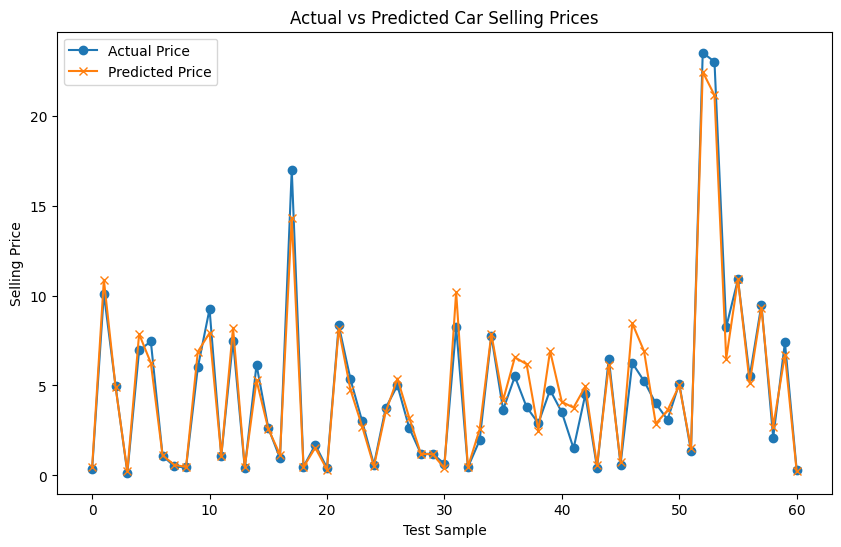

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker='o',
    label='Actual Price'
)

plt.plot(
    range(len(y_test)),
    forest_pred,
    marker='x',
    label='Predicted Price'
)

plt.xlabel('Test Sample')
plt.ylabel('Selling Price')
plt.title('Actual vs Predicted Car Selling Prices')
plt.legend()
plt.show()

In [32]:
# Final Model Summary

best_model = results_df.loc[results_df['R2 Score'].idxmax()]

print("========== FINAL MODEL SUMMARY ==========")
print("Best Model:", best_model['Model'])
print(f"MAE: {best_model['MAE']:.4f}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"R² Score: {best_model['R2 Score']:.4f}")
print("=========================================")

========== FINAL MODEL SUMMARY ==========
Best Model: Random Forest
MAE: 0.6308
RMSE: 0.9495
R² Score: 0.9609


## 📌 Key Findings

- The dataset contains 301 car records and 9 original features.
- There were no missing values in the dataset.
- Present Price has the strongest relationship with Selling Price, with a correlation of 0.88.
- Car Age and Driven Kilometers also contribute to price prediction.
- Three regression models were trained and evaluated:
  - Linear Regression
  - Decision Tree Regressor
  - Random Forest Regressor
- Random Forest achieved the best performance.
- Random Forest obtained an R² score of 0.9609 on the test data.
- The Random Forest model also achieved the lowest MAE and RMSE among the tested models.
- Feature importance analysis showed that Present Price was the most influential feature.

## 📝 Conclusion

This project demonstrates how machine learning can be used to predict used-car selling prices based on vehicle characteristics.

After preprocessing the dataset and performing exploratory data analysis, several regression models were trained and compared. Among the tested models, the Random Forest Regressor provided the best performance with an R² score of 0.9609.

The analysis also showed that Present Price is the most influential feature for predicting Selling Price.

The project demonstrates the practical application of machine learning for automobile price estimation and provides a foundation for developing data-driven car pricing systems.